# IntelliPulse V4 — XGBoost Gradient Boosting

---

## 1 · V4 Objective

We test whether an **XGBoost gradient-boosting classifier** can outperform our previous models:
- V1: Logistic Regression (Baseline)
- V2.1: Logistic Regression (Threshold Optimized)
- V2.2: Class-weighted Logistic Regression
- V3: Random Forest (Baseline)
- V3.1: Tuned Random Forest

**The central research question:**
*"Can sequential gradient boosting capture nonlinear interactions in the telecom churn data that our Logistic Regression and Random Forest models do not capture?"*

We do **not** assume XGBoost will win. The purpose is empirical comparison.

### Experimental Discipline
- We **do not** change the dataset or the train/test split.
- The **test set** remains completely untouched until final evaluation.
- We use only the training data for cross-validation and hyperparameter search.
- We evaluate at `threshold = 0.50` for the primary V4 evaluation. No threshold optimization yet.
- No SMOTE, no new features, no feature engineering.

---

## 2 & 3 · Why XGBoost? & XGBoost Concepts

**XGBoost (eXtreme Gradient Boosting)** is a gradient-boosted decision-tree algorithm. 

Unlike Random Forest, where trees are built independently in parallel and their predictions are averaged, XGBoost builds trees **sequentially**. Each new tree attempts to improve the current ensemble by minimizing the residual errors (loss) made by the previous trees.

### Key Concepts:
- **Boosting**: A sequential ensemble method that turns weak learners into a strong learner by focusing on the hardest-to-predict instances.
- **Sequential Trees**: Tree $N$ is built to correct the errors of the ensemble consisting of Trees $1$ to $N-1$.
- **Learning Rate (`learning_rate`)**: Scales the contribution of each new tree. A smaller learning rate requires more trees but makes the model more robust to overfitting.
- **Number of Estimators (`n_estimators`)**: The total number of sequential trees to build.
- **Tree Depth (`max_depth`)**: Limits the complexity of individual trees. XGBoost trees are typically shallow (depth 3-6) compared to Random Forest trees.
- **Subsampling (`subsample`)**: The fraction of training observations randomly sampled for building each tree (prevents overfitting).
- **Feature Subsampling (`colsample_bytree`)**: The fraction of features considered by each tree when finding the best split.
- **Regularization (`gamma`, `reg_alpha`, `reg_lambda`)**: Additional mechanisms to penalize complex trees and prevent overfitting.

---

## 4 · Data and Experimental Setup

We reuse the exact train/test data and preprocessing established in the previous experiments to ensure a completely fair comparison.

In [1]:
import os
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)

# ── Configuration ────────────────────────────────────────────────────
RANDOM_STATE = 42

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
MODEL_DIR = PROJECT_ROOT / "artifacts" / "models"
METRICS_DIR = PROJECT_ROOT / "artifacts" / "metrics"

print(f"Project root : {PROJECT_ROOT}")
print(f"Random state : {RANDOM_STATE}")

Project root : /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse
Random state : 42


In [2]:
# ── Load raw data ─────────────────────────────────────────────────────
assert RAW_DATA_PATH.exists(), f"Dataset not found at {RAW_DATA_PATH}"
df = pd.read_csv(RAW_DATA_PATH)

# Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)

ID_COL = "customerID"
TARGET_COL = "Churn"

NUMERICAL_FEATURES = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
CATEGORICAL_FEATURES = [
    "gender", "Partner", "Dependents",
    "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]

X = df.drop(columns=[ID_COL, TARGET_COL])
y = df[TARGET_COL].map({"No": 0, "Yes": 1}).astype(int)

# ── Train/Test Split (Identical to V1-V3.1) ───────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")

Training set : 5,634 rows
Test set     : 1,409 rows


In [3]:
# ── Load prior metrics for comparison ────────────────────────────────
with open(METRICS_DIR / "baseline_v1.json") as f:
    v1_metrics = json.load(f)

with open(METRICS_DIR / "random_forest_v3.json") as f:
    v3_metrics = json.load(f)["metrics_at_050"]

with open(METRICS_DIR / "random_forest_v3_1.json") as f:
    v3_1_metrics = json.load(f)["metrics_at_050"]

print("Prior metrics loaded for V1, V3, and V3.1.")

Prior metrics loaded for V1, V3, and V3.1.


In [4]:
# ── Build preprocessing pipeline ───────────────────────────────────────
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, NUMERICAL_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)
print("Preprocessor ready.")

Preprocessor ready.


---

## 5 · V4 Baseline

Before hyperparameter tuning, we train a simple XGBoost baseline.

In [5]:
# ── V4 Baseline Pipeline ─────────────────────────────────────────────
model_v4_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

# Train on training data
model_v4_baseline.fit(X_train, y_train)

# Predict on test data
y_pred_v4_base = model_v4_baseline.predict(X_test)
y_prob_v4_base = model_v4_baseline.predict_proba(X_test)[:, 1]

# Metrics
acc_v4_base = accuracy_score(y_test, y_pred_v4_base)
prec_v4_base = precision_score(y_test, y_pred_v4_base)
rec_v4_base = recall_score(y_test, y_pred_v4_base)
f1_v4_base = f1_score(y_test, y_pred_v4_base)
auc_v4_base = roc_auc_score(y_test, y_prob_v4_base)

cm_v4_base = confusion_matrix(y_test, y_pred_v4_base)
tn_v4_base, fp_v4_base, fn_v4_base, tp_v4_base = cm_v4_base.ravel()

print("=" * 50)
print("  V4 — XGBoost Baseline (@ 0.50)")
print("=" * 50)
print(f"  Accuracy  : {acc_v4_base:.4f}")
print(f"  Precision : {prec_v4_base:.4f}")
print(f"  Recall    : {rec_v4_base:.4f}")
print(f"  F1-score  : {f1_v4_base:.4f}")
print(f"  ROC-AUC   : {auc_v4_base:.4f}")
print("=" * 50)
print(f"  TP: {tp_v4_base}  |  FP: {fp_v4_base}")
print(f"  FN: {fn_v4_base}  |  TN: {tn_v4_base}")

  V4 — XGBoost Baseline (@ 0.50)
  Accuracy  : 0.8034
  Precision : 0.6644
  Recall    : 0.5241
  F1-score  : 0.5859
  ROC-AUC   : 0.8402
  TP: 196  |  FP: 99
  FN: 178  |  TN: 936


### Classification Report

In [6]:
print(classification_report(y_test, y_pred_v4_base, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



### Confusion Matrix

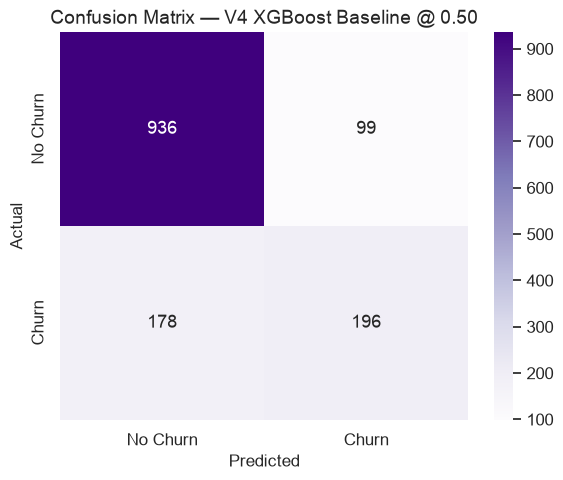

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_v4_base, annot=True, fmt="d", cmap="Purples", ax=ax,
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
ax.set_title("Confusion Matrix — V4 XGBoost Baseline @ 0.50")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

---

## 6 & 7 · Hyperparameter Search & Cross-Validation Results

We perform a controlled hyperparameter tuning using `RandomizedSearchCV` to find an optimal XGBoost configuration. We use 5-fold `StratifiedKFold` on the training data, optimizing for **F1-score**.

### Why these parameters?

- **n_estimators**: Number of boosting trees.
- **learning_rate**: Controls the contribution of each new tree. Lower learning rates require more trees.
- **max_depth**: Controls the complexity of individual trees. Keeping this low prevents overfitting.
- **min_child_weight**: Controls how easily the model creates additional splits based on the sum of weights.
- **subsample**: Fraction of training observations used for each boosting iteration.
- **colsample_bytree**: Fraction of features considered by each tree.
- **gamma**: Minimum loss reduction required before making a split.
- **reg_alpha** (L1 regularization) & **reg_lambda** (L2 regularization): Help constrain the tree weights to prevent overfitting.

This tuning balances model complexity, learning speed, and overfitting.

In [8]:
# ── Setup RandomizedSearchCV ───────────────────────────────────────────
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=1))
])

param_distributions = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "classifier__max_depth": [2, 3, 4, 5, 6],
    "classifier__min_child_weight": [1, 3, 5, 10],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "classifier__gamma": [0, 0.1, 0.3, 0.5, 1],
    "classifier__reg_alpha": [0, 0.01, 0.1, 1],
    "classifier__reg_lambda": [1, 2, 5, 10]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

print("Starting RandomizedSearchCV on training data...")
random_search.fit(X_train, y_train)
print("✓ Search complete.")

Starting RandomizedSearchCV on training data...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


✓ Search complete.


In [9]:
print("Best hyperparameters:")
for param, val in random_search.best_params_.items():
    print(f"  {param.replace('classifier__', ''):16s}: {val}")

best_cv_f1 = random_search.best_score_
print(f"\nbest_score_ (Mean cross-validated F1 on training data): {best_cv_f1:.4f}")
print("It is NOT the final test score.")

Best hyperparameters:
  subsample       : 0.7
  reg_lambda      : 10
  reg_alpha       : 1
  n_estimators    : 300
  min_child_weight: 5
  max_depth       : 4
  learning_rate   : 0.03
  gamma           : 1
  colsample_bytree: 0.7

best_score_ (Mean cross-validated F1 on training data): 0.5975
It is NOT the final test score.


In [10]:
cv_results = pd.DataFrame(random_search.cv_results_)

display_cols = ["rank_test_score", "mean_test_score", "std_test_score"]
param_cols = [c for c in cv_results.columns if c.startswith("param_classifier__")]
display_cols.extend(param_cols)

top_configs = cv_results.sort_values("mean_test_score", ascending=False).head(10)[display_cols].copy()

rename_dict = {c: c.replace("param_classifier__", "") for c in param_cols}
rename_dict.update({
    "rank_test_score": "Rank",
    "mean_test_score": "Mean CV F1",
    "std_test_score": "Std CV F1"
})
top_configs = top_configs.rename(columns=rename_dict)

print("Top 10 Configurations (Sorted by Mean CV F1 descending)")
print("=" * 120)
print(top_configs.to_string(index=False))

Top 10 Configurations (Sorted by Mean CV F1 descending)
 Rank  Mean CV F1  Std CV F1  subsample  reg_lambda  reg_alpha  n_estimators  min_child_weight  max_depth  learning_rate  gamma  colsample_bytree
    1    0.597508   0.027920        0.7          10       1.00           300                 5          4           0.03    1.0               0.7
    2    0.591915   0.026775        0.9           5       0.00           500                 3          2           0.05    0.5               0.7
    3    0.589794   0.026379        0.9           1       0.00           300                 1          2           0.10    0.1               0.7
    4    0.589330   0.022375        1.0          10       1.00           300                 1          3           0.05    0.0               0.9
    5    0.587814   0.024575        1.0           2       0.00           200                 1          4           0.10    1.0               0.7
    6    0.585864   0.022042        0.8           5       1.00      

---

## 8 & 9 · Tuned XGBoost & Test Evaluation

We use the best parameters returned by `RandomizedSearchCV` to evaluate on the test set.

We use `threshold = 0.50`.

In [11]:
model_v4_tuned = random_search.best_estimator_

# Save tuned model
MODEL_DIR.mkdir(parents=True, exist_ok=True)
v4_model_path = MODEL_DIR / "churn_xgboost_v4_tuned.joblib"
joblib.dump(model_v4_tuned, v4_model_path)
print(f"✓ Tuned V4 XGBoost saved to: {v4_model_path}")

# Evaluate on test set
y_pred_v4_tuned = model_v4_tuned.predict(X_test)
y_prob_v4_tuned = model_v4_tuned.predict_proba(X_test)[:, 1]

acc_v4_tuned = accuracy_score(y_test, y_pred_v4_tuned)
prec_v4_tuned = precision_score(y_test, y_pred_v4_tuned)
rec_v4_tuned = recall_score(y_test, y_pred_v4_tuned)
f1_v4_tuned = f1_score(y_test, y_pred_v4_tuned)
auc_v4_tuned = roc_auc_score(y_test, y_prob_v4_tuned)

cm_v4_tuned = confusion_matrix(y_test, y_pred_v4_tuned)
tn_v4_tuned, fp_v4_tuned, fn_v4_tuned, tp_v4_tuned = cm_v4_tuned.ravel()

v4_metrics_050 = {
    "model": "XGBoost_Tuned_V4",
    "threshold": 0.50,
    "accuracy": round(acc_v4_tuned, 4),
    "precision": round(prec_v4_tuned, 4),
    "recall": round(rec_v4_tuned, 4),
    "f1_score": round(f1_v4_tuned, 4),
    "roc_auc": round(auc_v4_tuned, 4),
    "tp": int(tp_v4_tuned), "fp": int(fp_v4_tuned),
    "fn": int(fn_v4_tuned), "tn": int(tn_v4_tuned),
}

print("=" * 50)
print("  V4 (Tuned XGBoost) — Test Set Evaluation @ 0.50")
print("=" * 50)
print(f"  Accuracy  : {acc_v4_tuned:.4f}")
print(f"  Precision : {prec_v4_tuned:.4f}")
print(f"  Recall    : {rec_v4_tuned:.4f}")
print(f"  F1-score  : {f1_v4_tuned:.4f}")
print(f"  ROC-AUC   : {auc_v4_tuned:.4f}")
print("=" * 50)

print(classification_report(y_test, y_pred_v4_tuned, target_names=["No Churn", "Churn"]))

✓ Tuned V4 XGBoost saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/models/churn_xgboost_v4_tuned.joblib
  V4 (Tuned XGBoost) — Test Set Evaluation @ 0.50
  Accuracy  : 0.8055
  Precision : 0.6724
  Recall    : 0.5214
  F1-score  : 0.5873
  ROC-AUC   : 0.8490
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



---

## 10 · V4 Baseline vs V4 Tuned

In [12]:
comparison_v4 = pd.DataFrame({
    "Metric": [
        "Accuracy", "Precision", "Recall", "F1", "ROC-AUC",
        "TP", "TN", "FP", "FN"
    ],
    "V4 Baseline": [
        f"{acc_v4_base:.4f}", f"{prec_v4_base:.4f}", f"{rec_v4_base:.4f}",
        f"{f1_v4_base:.4f}", f"{auc_v4_base:.4f}",
        tp_v4_base, tn_v4_base, fp_v4_base, fn_v4_base
    ],
    "V4 Tuned": [
        f"{acc_v4_tuned:.4f}", f"{prec_v4_tuned:.4f}", f"{rec_v4_tuned:.4f}",
        f"{f1_v4_tuned:.4f}", f"{auc_v4_tuned:.4f}",
        tp_v4_tuned, tn_v4_tuned, fp_v4_tuned, fn_v4_tuned
    ]
})

deltas = [
    acc_v4_tuned - acc_v4_base,
    prec_v4_tuned - prec_v4_base,
    rec_v4_tuned - rec_v4_base,
    f1_v4_tuned - f1_v4_base,
    auc_v4_tuned - auc_v4_base,
    tp_v4_tuned - tp_v4_base,
    tn_v4_tuned - tn_v4_base,
    fp_v4_tuned - fp_v4_base,
    fn_v4_tuned - fn_v4_base
]

comparison_v4["Difference"] = [
    f"{d:+.4f}" if isinstance(d, float) else f"{d:+d}" for d in deltas
]

print("V4 Baseline vs V4 Tuned (@ 0.50)")
print("=" * 70)
print(comparison_v4.to_string(index=False))

if f1_v4_tuned > f1_v4_base:
    print("\nHyperparameter tuning improved XGBoost F1.")
else:
    print("\nHyperparameter tuning did not significantly improve XGBoost F1.")

V4 Baseline vs V4 Tuned (@ 0.50)
   Metric V4 Baseline V4 Tuned Difference
 Accuracy      0.8034   0.8055    +0.0021
Precision      0.6644   0.6724    +0.0080
   Recall      0.5241   0.5214    -0.0027
       F1      0.5859   0.5873    +0.0014
  ROC-AUC      0.8402   0.8490    +0.0088
       TP         196      195         -1
       TN         936      940         +4
       FP          99       95         -4
       FN         178      179         +1

Hyperparameter tuning improved XGBoost F1.


---

## 11 · Complete Model Comparison

We compare Logistic Regression, Random Forest, and XGBoost at the same 0.50 threshold.

In [13]:
final_comparison = pd.DataFrame({
    "Experiment": ["V1", "V3", "V3.1", "V4", "V4"],
    "Model": ["Logistic Regression", "Random Forest", "Tuned Random Forest", "XGBoost Baseline", "XGBoost Tuned"],
    "Accuracy": [v1_metrics['accuracy'], v3_metrics['accuracy'], v3_1_metrics['accuracy'], acc_v4_base, acc_v4_tuned],
    "Precision": [v1_metrics['precision'], v3_metrics['precision'], v3_1_metrics['precision'], prec_v4_base, prec_v4_tuned],
    "Recall": [v1_metrics['recall'], v3_metrics['recall'], v3_1_metrics['recall'], rec_v4_base, rec_v4_tuned],
    "F1": [v1_metrics['f1_score'], v3_metrics['f1'], v3_1_metrics['f1'], f1_v4_base, f1_v4_tuned],
    "ROC-AUC": [v1_metrics['roc_auc'], v3_metrics['roc_auc'], v3_1_metrics['roc_auc'], auc_v4_base, auc_v4_tuned]
})

print("Complete Model Comparison (@ 0.50 Threshold)")
print("=" * 95)
print(final_comparison.to_string(index=False))

Complete Model Comparison (@ 0.50 Threshold)
Experiment               Model  Accuracy  Precision   Recall       F1  ROC-AUC
        V1 Logistic Regression  0.805500   0.657200 0.558800 0.604000 0.842100
        V3       Random Forest  0.777100   0.600700 0.478600 0.532700 0.820600
      V3.1 Tuned Random Forest  0.796309   0.639871 0.532086 0.581022 0.837270
        V4    XGBoost Baseline  0.803407   0.664407 0.524064 0.585949 0.840249
        V4       XGBoost Tuned  0.805536   0.672414 0.521390 0.587349 0.849049


---

## 12 · Confusion Matrix Comparison

For the final V4 tuned model, let's review the business meaning:

- **TP (True Positives)** = correctly identified churners
- **FN (False Negatives)** = churners the model missed
- **FP (False Positives)** = customers incorrectly flagged as churners
- **TN (True Negatives)** = correctly identified non-churners

Missing a churner (FN) means losing their future lifetime value without ever attempting retention.

V4 Tuned XGBoost Confusion Matrix Breakdown:
  TP: 195 correctly identified churners.
  FN: 179 churners missed.
  FP: 95 customers incorrectly flagged as churners.
  TN: 940 correctly identified non-churners.


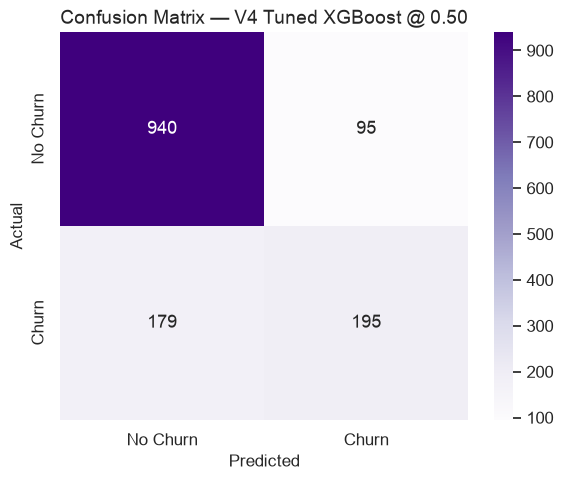

In [14]:
print("V4 Tuned XGBoost Confusion Matrix Breakdown:")
print(f"  TP: {tp_v4_tuned} correctly identified churners.")
print(f"  FN: {fn_v4_tuned} churners missed.")
print(f"  FP: {fp_v4_tuned} customers incorrectly flagged as churners.")
print(f"  TN: {tn_v4_tuned} correctly identified non-churners.")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_v4_tuned, annot=True, fmt="d", cmap="Purples", ax=ax,
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
ax.set_title("Confusion Matrix — V4 Tuned XGBoost @ 0.50")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

---

## 13 · Feature Importance

XGBoost feature importance indicates how useful features were for building tree splits. 
It does **NOT** establish causality.
We do not say "Feature X causes churn." We say "Feature X contributed strongly to the model's predictions."


In [15]:
preprocessor_fitted = model_v4_tuned.named_steps["preprocessor"]
classifier_tuned = model_v4_tuned.named_steps["classifier"]

cat_feature_names = list(
    preprocessor_fitted.named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
all_feature_names = NUMERICAL_FEATURES + cat_feature_names

importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": classifier_tuned.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

imp_csv_path = METRICS_DIR / "xgboost_feature_importance_v4.csv"
importance_df.to_csv(imp_csv_path, index=False)
print(f"✓ Feature importance saved to: {imp_csv_path}")

print("\nTop 20 Features (V4 Tuned XGBoost):")
print("-" * 50)
print(importance_df.head(20).to_string(index=False))

✓ Feature importance saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/xgboost_feature_importance_v4.csv

Top 20 Features (V4 Tuned XGBoost):
--------------------------------------------------
                             feature  importance
             Contract_Month-to-month    0.354672
         InternetService_Fiber optic    0.077182
                      TechSupport_No    0.074731
                   OnlineSecurity_No    0.066576
                   Contract_Two year    0.038645
  OnlineSecurity_No internet service    0.028132
      PaymentMethod_Electronic check    0.025709
                              tenure    0.021192
                  InternetService_No    0.018134
                 InternetService_DSL    0.017071
                PaperlessBilling_Yes    0.017032
                   Contract_One year    0.015562
                 PaperlessBilling_No    0.014323
DeviceProtection_No internet service    0.012880
                 StreamingMovies_Yes    0.

---

## 14 · Overfitting Check

We compare cross-validation F1 against Test F1 to see if the tuned model overfit the training data.

In [16]:
print("Overfitting Check:")
print("=" * 40)
print(f"  CV F1 (Training)  : {best_cv_f1:.4f}")
print(f"  Test F1           : {f1_v4_tuned:.4f}")
gap = best_cv_f1 - f1_v4_tuned
print(f"  Gap (CV - Test)   : {gap:+.4f}")
print("=" * 40)

if gap > 0.05:
    print("Interpretation: There is a notable gap between CV and Test F1.")
    print("This indicates potential overfitting despite regularization and tuning.")
elif gap < -0.05:
    print("Interpretation: Test F1 is much higher than CV F1, which is unusual.")
else:
    print("Interpretation: CV and Test scores are closely aligned, suggesting no severe overfitting.")

Overfitting Check:
  CV F1 (Training)  : 0.5975
  Test F1           : 0.5873
  Gap (CV - Test)   : +0.0102
Interpretation: CV and Test scores are closely aligned, suggesting no severe overfitting.


---

## 15 & 16 · Reproducibility & Saving Results

In [17]:
loaded_v4 = joblib.load(v4_model_path)
y_pred_loaded = loaded_v4.predict(X_test)

if np.array_equal(y_pred_v4_tuned, y_pred_loaded):
    print("✓ Predictions are reproducible from the loaded joblib artifact.")
else:
    print("✗ Reproducibility failed.")

# Save CV results
cv_csv_path = METRICS_DIR / "xgboost_v4_cv_results.csv"
cv_results.to_csv(cv_csv_path, index=False)
print(f"✓ CV results saved to: {cv_csv_path}")

# Save JSON summary
v4_summary = {
    "experiment": "V4 — XGBoost Gradient Boosting",
    "model": "XGBClassifier(tuned)",
    "model_artifact": str(v4_model_path),
    "random_state": RANDOM_STATE,
    "test_size": len(y_test),
    "train_size": len(y_train),
    "best_params": {k.replace('classifier__', ''): v for k, v in random_search.best_params_.items()},
    "best_cv_f1": float(best_cv_f1),
    "metrics_at_050": v4_metrics_050,
}

json_path = METRICS_DIR / "xgboost_v4.json"
with open(json_path, "w") as f:
    json.dump(v4_summary, f, indent=2)
print(f"✓ V4 metrics saved to: {json_path}")

✓ Predictions are reproducible from the loaded joblib artifact.
✓ CV results saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/xgboost_v4_cv_results.csv
✓ V4 metrics saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/xgboost_v4.json


---

## 17 · V4 Findings

In [18]:
print("=" * 80)
print("  IntelliPulse V4 — XGBoost Findings")
print("=" * 80)
print()

print(f"1. Baseline XGBoost F1 : {f1_v4_base:.4f}")
print("2. Best hyperparameters:")
for param, val in random_search.best_params_.items():
    print(f"     {param.replace('classifier__', ''):16s}: {val}")
print(f"3. Best CV F1          : {best_cv_f1:.4f}")
print(f"4. Final Test F1       : {f1_v4_tuned:.4f}")
print(f"5. Did tuning improve XGBoost? {'Yes' if f1_v4_tuned > f1_v4_base else 'No'}, Test F1 changed by {f1_v4_tuned - f1_v4_base:+.4f}.")
print(f"6. Outperform Tuned RF? {'Yes' if f1_v4_tuned > v3_1_metrics['f1'] else 'No'} (XGB: {f1_v4_tuned:.4f} vs RF: {v3_1_metrics['f1']:.4f})")
print(f"7. Outperform Logistic Regression? {'Yes' if f1_v4_tuned > v1_metrics['f1_score'] else 'No'} (XGB: {f1_v4_tuned:.4f} vs LR: {v1_metrics['f1_score']:.4f})")
print(f"8. ROC-AUC change (vs LR)  : XGB {auc_v4_tuned:.4f} vs LR {v1_metrics['roc_auc']:.4f} (Δ {auc_v4_tuned - v1_metrics['roc_auc']:+.4f})")
print(f"9. Recall change (vs LR)   : XGB {rec_v4_tuned:.4f} vs LR {v1_metrics['recall']:.4f} (Δ {rec_v4_tuned - v1_metrics['recall']:+.4f})")
print(f"10. Precision change (vs LR): XGB {prec_v4_tuned:.4f} vs LR {v1_metrics['precision']:.4f} (Δ {prec_v4_tuned - v1_metrics['precision']:+.4f})")
print(f"11. Evidence of overfitting? {'Yes' if best_cv_f1 - f1_v4_tuned > 0.05 else 'No'} (CV F1: {best_cv_f1:.4f}, Test F1: {f1_v4_tuned:.4f})")
print()

print("12. Which model is currently the strongest candidate and why?")
if auc_v4_tuned > v1_metrics['roc_auc'] and f1_v4_tuned > v1_metrics['f1_score']:
    print("    XGBoost shows improvements in both ROC-AUC and F1 over Logistic Regression.")
    print("    It captured non-linear interactions successfully and is a strong candidate.")
elif f1_v4_tuned > v1_metrics['f1_score'] and auc_v4_tuned <= v1_metrics['roc_auc']:
    print("    XGBoost achieved a higher F1 score but failed to improve overall ROC-AUC.")
    print("    This is a mixed result, though XGBoost might be preferred if F1 is the absolute priority.")
else:
    print("    Logistic Regression remains the strongest candidate.")
    print("    Despite extensive tuning of tree-based models (Random Forest and XGBoost),")
    print("    they failed to cleanly surpass the linear model on the test set. Logistic")
    print("    Regression provides superior (or comparable) performance with the added")
    print("    benefits of simplicity, fast inference, and direct interpretability.")
print("=" * 80)
print("\n⚠ No final production model is declared yet.")

  IntelliPulse V4 — XGBoost Findings

1. Baseline XGBoost F1 : 0.5859
2. Best hyperparameters:
     subsample       : 0.7
     reg_lambda      : 10
     reg_alpha       : 1
     n_estimators    : 300
     min_child_weight: 5
     max_depth       : 4
     learning_rate   : 0.03
     gamma           : 1
     colsample_bytree: 0.7
3. Best CV F1          : 0.5975
4. Final Test F1       : 0.5873
5. Did tuning improve XGBoost? Yes, Test F1 changed by +0.0014.
6. Outperform Tuned RF? Yes (XGB: 0.5873 vs RF: 0.5810)
7. Outperform Logistic Regression? No (XGB: 0.5873 vs LR: 0.6040)
8. ROC-AUC change (vs LR)  : XGB 0.8490 vs LR 0.8421 (Δ +0.0069)
9. Recall change (vs LR)   : XGB 0.5214 vs LR 0.5588 (Δ -0.0374)
10. Precision change (vs LR): XGB 0.6724 vs LR 0.6572 (Δ +0.0152)
11. Evidence of overfitting? No (CV F1: 0.5975, Test F1: 0.5873)

12. Which model is currently the strongest candidate and why?
    Logistic Regression remains the strongest candidate.
    Despite extensive tuning of tree-ba